# Libraries

In [561]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from mpmath import polylog
from scipy.integrate import quad, nquad
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import RectBivariateSpline
import pickle
from functools import lru_cache
import pandas as pd

# Constants

In [562]:
GeVsq_to_Erg_per_s = 2.435309496e21   # GeV^2 → erg/s
cm_to_invGeV       = 1 / (1.97e-5) * 1e9   # cm → GeV^-1
km_to_invGeV       = 1 / (1.97e-10) * 1e9  # km → GeV^-1
gram_to_GeV        = (1 / (1.78e-36)) * 1e-3 * 1e-9  # g → GeV

GF = 1.1663787e-5      # GeV^-2
Rc = 10 * 1e5          # cm
MN = 0.93956542052     # GeV
MW = 80.379            # GeV
MZ = 91.1876           # GeV
Tc = 0.03              # GeV
gA = 1.27

# Iterations

In [563]:
# rIte: radial grid
rIte = np.array([0.004*Rc * 10**(3/30*ii) for ii in range(31)])

# λ grid
LambdaIte = np.array([10**(-4 + (4/20)*jj) for jj in range(21)])

# m_phi grid
mphiIte = np.array([10**(-3 + (3/24)*kk) for kk in range(25)])

# E4 grid
E4Ite = np.array([10**(-2 + (4/30)*ll) for ll in range(31)])

# rIte30: alternative radial grid
rIte30 = np.array([0.003*Rc * 10**(4/40*mm) for mm in range(41)])

# SN Parameters

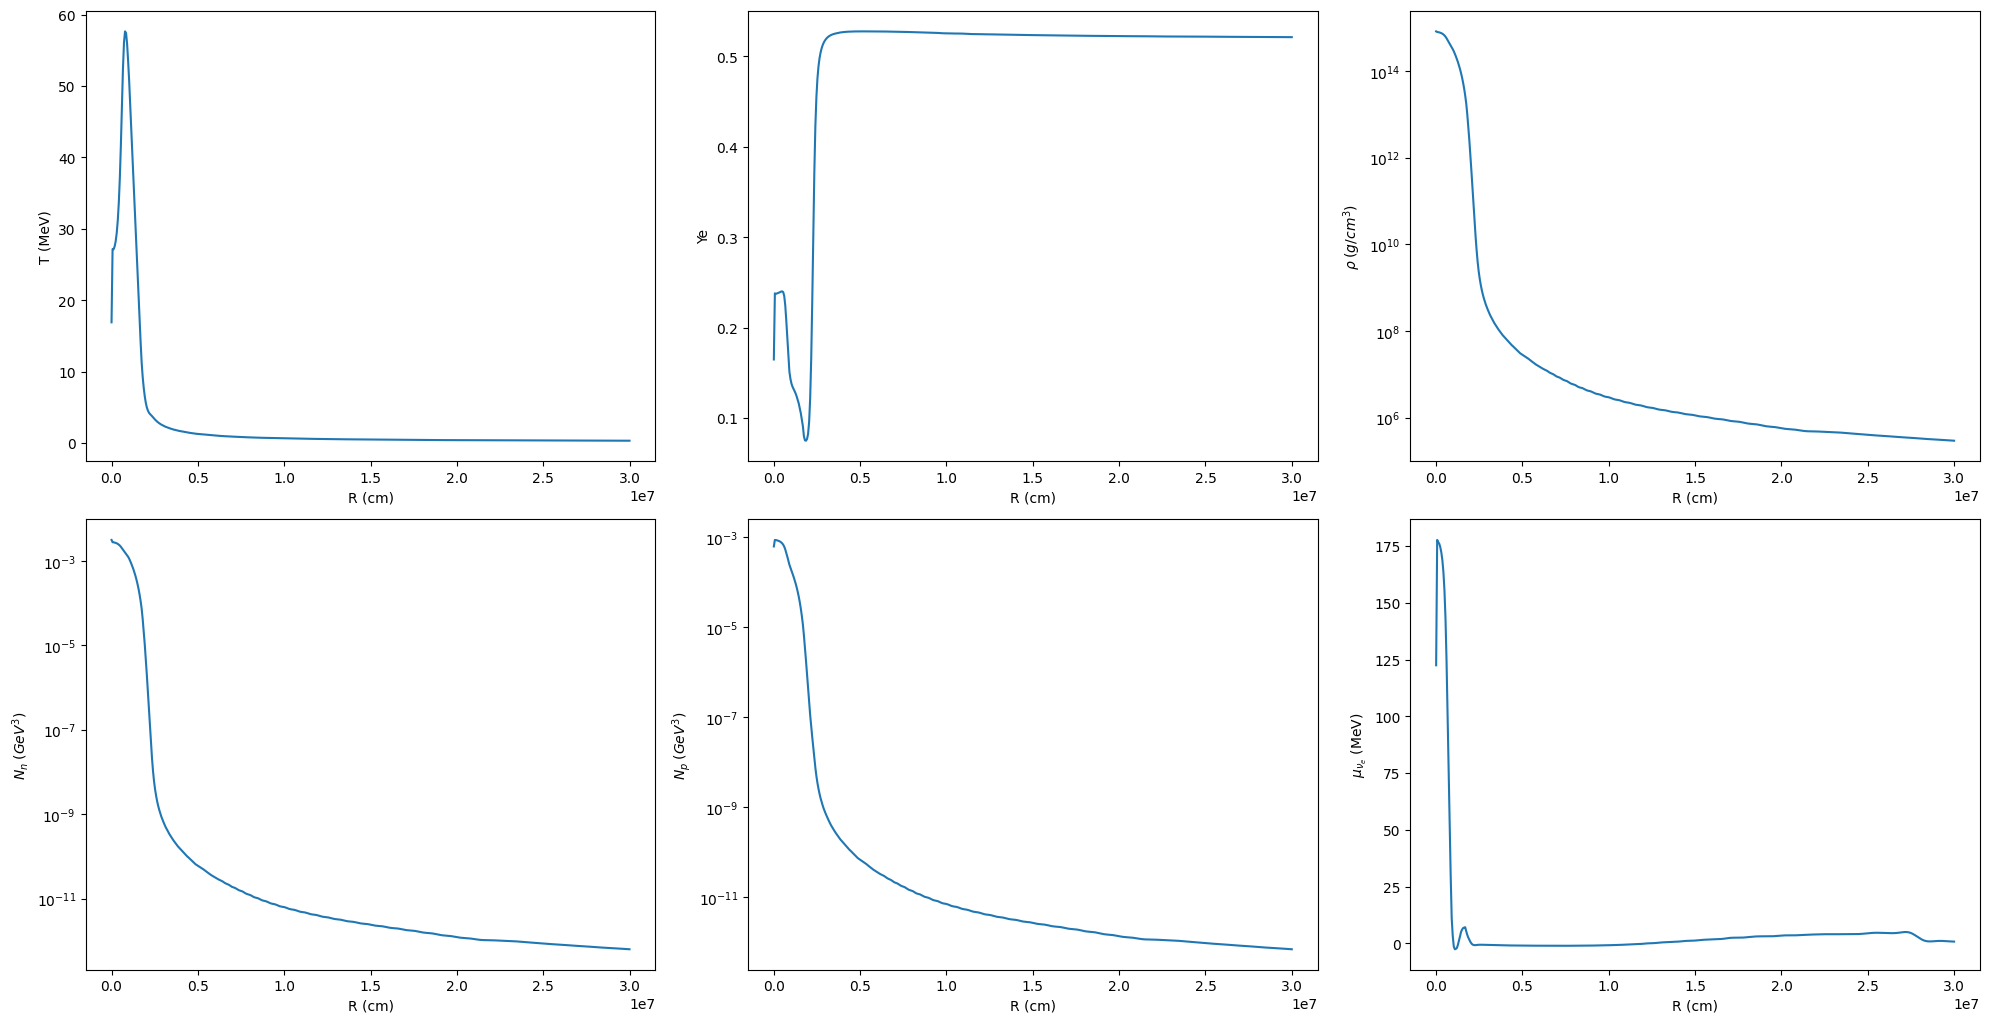

In [564]:
data = np.loadtxt("hydro-SFHo-s20.0-MUONS-T=1.0010874.txt")

r_vals = data[:, 0]  
T_interp   = interp1d(r_vals, data[:, 4],  kind='cubic', fill_value="extrapolate")   # col 5
Ye_interp  = interp1d(r_vals, data[:,19], kind='cubic', fill_value="extrapolate")   # col 20
rho_interp = interp1d(r_vals, data[:, 2],  kind='cubic', fill_value="extrapolate")  # col 3
mu_nu_interp = interp1d(r_vals, data[:, 8], kind='cubic', fill_value="extrapolate") # col 9

def T(r): return T_interp(r)
def Ye(r): return Ye_interp(r)
def rho(r): return rho_interp(r)
def mu_nu(r): return mu_nu_interp(r)
def nn(r):
    return rho(r) * gram_to_GeV * (cm_to_invGeV)**-3 / MN * (1 - Ye(r))
def np_(r):
    return Ye(r) / (1 - Ye(r)) * nn(r) 

r_grid = np.linspace(0, 30*Rc, 500)
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

axes[0].plot(r_grid, T(r_grid))
axes[0].set_xlabel("R (cm)")
axes[0].set_ylabel("T (MeV)")

axes[1].plot(r_grid, Ye(r_grid))
axes[1].set_xlabel("R (cm)")
axes[1].set_ylabel("Ye")

axes[2].semilogy(r_grid, rho(r_grid))
axes[2].set_xlabel("R (cm)")
axes[2].set_ylabel(r"$\rho \; (g/cm^3)$")

axes[3].semilogy(r_grid, nn(r_grid))
axes[3].set_xlabel("R (cm)")
axes[3].set_ylabel(r"$N_n \; (GeV^3)$")

axes[4].semilogy(r_grid, np_(r_grid))
axes[4].set_xlabel("R (cm)")
axes[4].set_ylabel(r"$N_p \; (GeV^3)$")

axes[5].plot(r_grid, mu_nu(r_grid))
axes[5].set_xlabel("R (cm)")
axes[5].set_ylabel(r"$\mu_{\nu_e}$ (MeV)")

for i in range(6, 9):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Interaction rates (SM + Phi)

In [565]:
def Gamma_SM_mu_tau(E4, r):
    return nn(r) * ((1 + 3*gA**2) * GF**2 * E4**2) / (4*np.pi)

def Gamma_SM_nue(E4, r, Sign):
    if Sign > 0:  # neutrino
        return Sign * 5 * nn(r) * ((1 + 3*gA**2) * GF**2 * E4**2) / (4*np.pi)
    elif Sign < 0:  # antineutrino
        return -Sign * (nn(r) + 4*np_(r)) * ((1 + 3*gA**2) * GF**2 * E4**2) / (4*np.pi)
    
def w(mphi, E4, r):
    return mphi**2 / (4 * E4 * (1e-3 * T(r)))

def Gamma_Light_phi_0mu(lmbda, mphi, E4, r):
    prefactor = (lmbda**2 * mphi**2 * (1e-3 * T(r))) / (16 * np.pi * E4**2)
    w_val = w(mphi, E4, r)
    return prefactor * (np.logaddexp(0.0, w_val) - w_val)

def Gamma_Light_phi_with_mu(lmbda, mphi, E4, r, Sign):
    prefactor = (lmbda**2 * mphi**2 * (1e-3 * T(r))) / (16 * np.pi * E4**2)
    w_val = w(mphi, E4, r)
    mu_term = Sign * mu_nu(r) / T(r)
    return prefactor * (np.logaddexp(mu_term, w_val) - w_val)


def Gamma_tot_0mu(lmbda, mphi, E4, r):
    return Gamma_SM_mu_tau(E4, r) + Gamma_Light_phi_0mu(lmbda, mphi, E4, r)


def Gamma_tot_with_mu(lmbda, mphi, E4, r, Sign):
    return Gamma_SM_nue(E4, r, Sign) + Gamma_Light_phi_with_mu(lmbda, mphi, E4, r, Sign)


# Potential (SM)

In [566]:
def VSM_0mu(r):
    term = (polylog(3, -np.exp(mu_nu(r)/T(r))) -
            polylog(3, -np.exp(-mu_nu(r)/T(r))))
    prefactor = -(3 * 1e-9 * T(r)**3) / (np.pi**2)
    return np.sqrt(2) * GF * (prefactor * term - 0.5 * nn(r))


def VSM_with_mu(r):
    term = (polylog(3, -np.exp(mu_nu(r)/T(r))) -
            polylog(3, -np.exp(-mu_nu(r)/T(r))))
    prefactor = -(6 * 1e-9 * T(r)**3) / (np.pi**2)
    return np.sqrt(2) * GF * (prefactor * term + np_(r) - 0.5 * nn(r))

# FD and BE

In [567]:
def FD(a, b, c):
    """Fermi-Dirac distribution: 1 / (exp((a-b)/c) + 1)"""
    return 1.0 / (np.exp((a - b) / c) + 1.0)

def BE(a, b, c):
    """Bose-Einstein distribution: 1 / (exp((a-b)/c) - 1)"""
    return 1.0 / (np.exp((a - b) / c) - 1.0)

# def FD(a, b, c):
#     """Fermi-Dirac distribution: 1 / (exp((a-b)/c) + 1), with overflow safety"""
#     y = (a - b) / c
#     if y > 50.0:
#         return 0.0
#     if y < -50.0:
#         return 1.0
#     if y >= 0.0:
#         ey = np.exp(-y)  # safe for large positive y
#         return ey / (1.0 + ey)
#     else:
#         ey = np.exp(y)   # safe for large negative y
#         return 1.0 / (1.0 + ey)

# def BE(a, b, c):
#     """Bose-Einstein distribution: 1 / (exp((a-b)/c) - 1), with overflow safety"""
#     y = (a - b) / c
#     if y > 50.0:
#         return 0.0
#     # prevent division by zero for very small y
#     return 1.0 / np.expm1(max(y, 1e-12))

# Potential (Phi) [Exact]

In [568]:
# def Vphi0mu_integral(mphi, E4, r):
#     Tr = 1e-3 * T(r)  # temperature in GeV
#     mu = mu_nu(r)     # chemical potential (not used here)

#     # First FD integral
#     def integrand_fd(k):
#         term1 = (mphi**2 / (2*E4**2)) * np.log(mphi**2 / (mphi**2 + 4*E4*k)) + (2*k)/E4
#         term2 = (-mphi**2 / (2*E4**2)) * np.log(mphi**2 / (mphi**2 - 4*E4*k)) + (2*k)/E4
#         return term1 * FD(k, 0, Tr) + term2 * FD(k, 0, Tr)

#     # Second BE integral
#     def integrand_be(k):
#         Ek = np.sqrt(k**2 + mphi**2)
#         logp = np.log((mphi**2 + 2*E4*k + 2*E4*Ek) / (mphi**2 - 2*E4*k + 2*E4*Ek))
#         logm = np.log((mphi**2 + 2*E4*k - 2*E4*Ek) / (mphi**2 - 2*E4*k - 2*E4*Ek))
#         term1 = k/Ek * ((2*k)/E4 - (mphi**2/(2*E4**2))*logp) * BE(Ek, 0, Tr)
#         term2 = k/Ek * ((2*k)/E4 - (mphi**2/(2*E4**2))*logm) * BE(Ek, 0, Tr)
#         return term1 + term2

#     I_fd, _ = quad(integrand_fd, 0, np.inf, limit=200)
#     I_be, _ = quad(integrand_be, 0, np.inf, limit=200)
    
#     return np.real(I_fd + I_be)

# def Vphi_with_mu_integral(mphi, E4, r):
#     Tr = 1e-3 * T(r)
#     mu = 1e-3 * mu_nu(r)  # scaled chemical potential

#     # First FD integral
#     def integrand_fd(k):
#         term1 = (mphi**2 / (2*E4**2)) * np.log(mphi**2 / (mphi**2 + 4*E4*k)) + (2*k)/E4
#         term2 = (-mphi**2 / (2*E4**2)) * np.log(mphi**2 / (mphi**2 - 4*E4*k)) + (2*k)/E4
#         return term1 * FD(k, -mu, Tr) + term2 * FD(k, +mu, Tr)

#     # Second BE integral
#     def integrand_be(k):
#         Ek = np.sqrt(k**2 + mphi**2)
#         logp = np.log((mphi**2 + 2*E4*k + 2*E4*Ek) / (mphi**2 - 2*E4*k + 2*E4*Ek))
#         logm = np.log((mphi**2 + 2*E4*k - 2*E4*Ek) / (mphi**2 - 2*E4*k - 2*E4*Ek))
#         term1 = k/Ek * ((2*k)/E4 - (mphi**2/(2*E4**2))*logp) * BE(Ek, +2*mu, Tr)
#         term2 = k/Ek * ((2*k)/E4 - (mphi**2/(2*E4**2))*logm) * BE(Ek, -2*mu, Tr)
#         return term1 + term2

#     I_fd, _ = quad(integrand_fd, 0, np.inf, limit=200)
#     I_be, _ = quad(integrand_be, 0, np.inf, limit=200)
    
#     return np.real(I_fd + I_be)

# def Vphi_with_mu_integral_bar(mphi, E4, r):
#     """
#     Computes Vϕ_withμIntegralbar(mphi, E4, r)
#     (antineutrino case, μν signs flipped).
#     """
#     Tr = 1e-3 * T(r)       # temperature (GeV)
#     mu = 1e-3 * mu_nu(r)   # scaled chemical potential

#     # First FD integral
#     def integrand_fd(k):
#         term1 = (mphi**2 / (2*E4**2)) * np.log(mphi**2 / (mphi**2 + 4*E4*k)) + (2*k)/E4
#         term2 = (-mphi**2 / (2*E4**2)) * np.log(mphi**2 / (mphi**2 - 4*E4*k)) + (2*k)/E4
#         return term1 * FD(k, +mu, Tr) + term2 * FD(k, -mu, Tr)

#     # Second BE integral
#     def integrand_be(k):
#         Ek = np.sqrt(k**2 + mphi**2)
#         logp = np.log((mphi**2 + 2*E4*k + 2*E4*Ek) / (mphi**2 - 2*E4*k + 2*E4*Ek))
#         logm = np.log((mphi**2 + 2*E4*k - 2*E4*Ek) / (mphi**2 - 2*E4*k - 2*E4*Ek))
#         term1 = k/Ek * ((2*k)/E4 - (mphi**2/(2*E4**2))*logp) * BE(Ek, -2*mu, Tr)
#         term2 = k/Ek * ((2*k)/E4 - (mphi**2/(2*E4**2))*logm) * BE(Ek, +2*mu, Tr)
#         return term1 + term2

#     I_fd, _ = quad(integrand_fd, 0, np.inf, limit=200)
#     I_be, _ = quad(integrand_be, 0, np.inf, limit=200)

#     return np.real(I_fd + I_be)

# Potential (Phi) [Optimised]

In [611]:
def Vphi0mu_nocache_ifeps(mphi, E4, r, delta=1e-8, epsabs=1e-6, epsrel=1e-4):
    Tr = 1e-3 * T(r)
    mphi_safe = max(float(mphi), 1e-12)
    E4_safe = max(float(E4), 1e-12)
    Tr_safe = max(float(Tr), 1e-12)

    def integrand_fd(k):
        denom_p = mphi_safe**2 + 4*E4_safe*k + 1j*delta
        denom_m = mphi_safe**2 - 4*E4_safe*k + 1j*delta
        term1 = (mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_p) + (2*k)/E4_safe
        term2 = (-mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_m) + (2*k)/E4_safe
        val = (term1 + term2) * FD(k, 0, Tr_safe)
        return np.real(val)  # integrate real part for a PV-like result

    def integrand_be(k):
        Ek = np.sqrt(k*k + mphi_safe*mphi_safe)
        denom1p = mphi_safe**2 + 2*E4_safe*k + 2*E4_safe*Ek + 1j*delta
        denom1m = mphi_safe**2 - 2*E4_safe*k + 2*E4_safe*Ek + 1j*delta
        denom2p = mphi_safe**2 + 2*E4_safe*k - 2*E4_safe*Ek + 1j*delta
        denom2m = mphi_safe**2 - 2*E4_safe*k - 2*E4_safe*Ek + 1j*delta
        logp = np.log(denom1p / denom1m)
        logm = np.log(denom2p / denom2m)
        term1 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logp) * BE(Ek, 0, Tr_safe)
        term2 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logm) * BE(Ek, 0, Tr_safe)
        return np.real(term1 + term2)

    I_fd, _ = quad(integrand_fd, 1e-8, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
    I_be, _ = quad(integrand_be, 1e-8, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
    return I_fd + I_be

def Vphi0mu_integral(mphi, E4, r):
    return Vphi0mu_nocache_ifeps(mphi, E4, r)


################################################################################################################################################################


def Vphimu_nocache_ifeps(mphi, E4, r, epsabs=1e-6, epsrel=1e-4, delta=1e-8):
    """
    Same as Vphimu_nocache, but uses a small imaginary shift (i*delta) in denominators
    to regularize singularities, following the Feynman prescription.
    """

    Tr = 1e-3 * T(r)      # temperature in GeV
    mu = 1e-3 * mu_nu(r)  # chemical potential (GeV)

    # Protect against zero or tiny inputs
    mphi_safe = max(float(mphi), 1e-12)
    E4_safe   = max(float(E4), 1e-12)
    Tr_safe   = max(float(Tr), 1e-12)

    # --- FD integrand ---
    def integrand_fd(k):
        denom_p = mphi_safe**2 + 4*E4_safe*k + 1j*delta
        denom_m = mphi_safe**2 - 4*E4_safe*k + 1j*delta

        term1 = (mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_p) + (2*k)/E4_safe
        term2 = (-mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_m) + (2*k)/E4_safe

        val = term1 * FD(k, -mu, Tr_safe) + term2 * FD(k, +mu, Tr_safe)
        return np.real(val)  # quad expects real integrand

    # --- BE integrand ---
    def integrand_be(k):
        Ek = np.sqrt(k*k + mphi_safe*mphi_safe)

        denom1p = mphi_safe**2 + 2*E4_safe*k + 2*E4_safe*Ek + 1j*delta
        denom1m = mphi_safe**2 - 2*E4_safe*k + 2*E4_safe*Ek + 1j*delta
        denom2p = mphi_safe**2 + 2*E4_safe*k - 2*E4_safe*Ek + 1j*delta
        denom2m = mphi_safe**2 - 2*E4_safe*k - 2*E4_safe*Ek + 1j*delta

        logp = np.log(denom1p / denom1m)
        logm = np.log(denom2p / denom2m)

        term1 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logp) * BE(Ek, +2*mu, Tr_safe)
        term2 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logm) * BE(Ek, -2*mu, Tr_safe)

        return np.real(term1 + term2)

    # Integrate
    I_fd, _ = quad(integrand_fd, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
    I_be, _ = quad(integrand_be, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)

    return I_fd + I_be

def Vphi_with_mu_integral(mphi, E4, r):
    return Vphimu_nocache_ifeps(mphi, E4, r)


################################################################################################################################################################
def Vphimubar_nocache_ifeps(mphi, E4, r, epsabs=1e-6, epsrel=1e-4, delta=1e-8):
    """
    Regularized version of Vphimubar_nocache using a small imaginary shift (i*delta)
    in denominators to avoid singularities, following the Feynman prescription.
    """

    Tr = 1e-3 * T(r)      # temperature in GeV
    mu = 1e-3 * mu_nu(r)  # chemical potential (GeV)

    # Protect against zero or tiny inputs
    mphi_safe = max(float(mphi), 1e-12)
    E4_safe   = max(float(E4), 1e-12)
    Tr_safe   = max(float(Tr), 1e-12)

    # --- FD integrand ---
    def integrand_fd(k):
        denom_p = mphi_safe**2 + 4*E4_safe*k + 1j*delta
        denom_m = mphi_safe**2 - 4*E4_safe*k + 1j*delta

        term1 = (mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_p) + (2*k)/E4_safe
        term2 = (-mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_m) + (2*k)/E4_safe

        val = term1 * FD(k, +mu, Tr_safe) + term2 * FD(k, -mu, Tr_safe)
        return np.real(val)  # integrate only the real part

    # --- BE integrand ---
    def integrand_be(k):
        Ek = np.sqrt(k*k + mphi_safe*mphi_safe)

        denom1p = mphi_safe**2 + 2*E4_safe*k + 2*E4_safe*Ek + 1j*delta
        denom1m = mphi_safe**2 - 2*E4_safe*k + 2*E4_safe*Ek + 1j*delta
        denom2p = mphi_safe**2 + 2*E4_safe*k - 2*E4_safe*Ek + 1j*delta
        denom2m = mphi_safe**2 - 2*E4_safe*k - 2*E4_safe*Ek + 1j*delta

        logp = np.log(denom1p / denom1m)
        logm = np.log(denom2p / denom2m)

        term1 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logp) * BE(Ek, -2*mu, Tr_safe)
        term2 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logm) * BE(Ek, +2*mu, Tr_safe)

        return np.real(term1 + term2)

    # Integrate both contributions
    I_fd, _ = quad(integrand_fd, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
    I_be, _ = quad(integrand_be, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)

    return I_fd + I_be

def Vphi_with_mu_integral_bar(mphi, E4, r):
    return Vphimubar_nocache_ifeps(mphi, E4, r)

In [570]:
# ####################################Vphi0mu###############################

# def Vphi0mu_nocache(mphi, E4, r, epsabs=1e-6, epsrel=1e-4):
#     Tr = 1e-3 * T(r)  # temperature in GeV
#     mu = mu_nu(r)     # chemical potential (not used here)

#     # Protect against zero or tiny inputs
#     mphi_safe = max(float(mphi), 1e-12)
#     E4_safe = max(float(E4), 1e-12)
#     Tr_safe = max(float(Tr), 1e-12)

#     # First FD integral
#     def integrand_fd(k):
#         denom_p = mphi_safe**2 + 4*E4_safe*k
#         denom_m = mphi_safe**2 - 4*E4_safe*k
#         # Protect against log of negative/zero
#         if denom_p <= 0 or denom_m <= 0:
#             return 0.0

#         term1 = (mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_p) + (2*k)/E4_safe
#         term2 = (-mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_m) + (2*k)/E4_safe
#         return term1 * FD(k, 0, Tr_safe) + term2 * FD(k, 0, Tr_safe)

#     # Second BE integral
#     def integrand_be(k):
#         Ek = np.sqrt(k*k + mphi_safe*mphi_safe)
#         denom1p = mphi_safe**2 + 2*E4_safe*k + 2*E4_safe*Ek
#         denom1m = mphi_safe**2 - 2*E4_safe*k + 2*E4_safe*Ek
#         denom2p = mphi_safe**2 + 2*E4_safe*k - 2*E4_safe*Ek
#         denom2m = mphi_safe**2 - 2*E4_safe*k - 2*E4_safe*Ek

#         # Avoid invalid logs
#         if denom1p <= 0 or denom1m <= 0 or denom2p <= 0 or denom2m <= 0:
#             return 0.0

#         logp = np.log(denom1p / denom1m)
#         logm = np.log(denom2p / denom2m)

#         term1 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logp) * BE(Ek, 0, Tr_safe)
#         term2 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logm) * BE(Ek, 0, Tr_safe)
#         return term1 + term2

#     I_fd, _ = quad(integrand_fd, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
#     I_be, _ = quad(integrand_be, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)

#     return np.real(I_fd + I_be)

# # Quantized cache wrapper
# @lru_cache(maxsize=8192)
# def _Vphi0mu_cached(mphi_q, E4_q, r_q):
#     return Vphi0mu_nocache(mphi_q, E4_q, r_q)

# def Vphi0mu_integral(mphi, E4, r, quant=6):
#     mphi_q = float(np.round(mphi, quant))
#     E4_q   = float(np.round(E4, quant))
#     r_q    = float(np.round(r, quant))  # careful: depends if r is continuous
#     return _Vphi0mu_cached(mphi_q, E4_q, r_q)


# ####################################Vphimu###############################


# def Vphimu_nocache(mphi, E4, r, epsabs=1e-6, epsrel=1e-4):
#     Tr = 1e-3 * T(r)  # temperature in GeV
#     mu = 1e-3 * mu_nu(r)     # chemical potential (not used here)

#     # Protect against zero or tiny inputs
#     mphi_safe = max(float(mphi), 1e-12)
#     E4_safe = max(float(E4), 1e-12)
#     Tr_safe = max(float(Tr), 1e-12)

#     # First FD integral
#     def integrand_fd(k):
#         denom_p = mphi_safe**2 + 4*E4_safe*k
#         denom_m = mphi_safe**2 - 4*E4_safe*k
#         # Protect against log of negative/zero
#         if denom_p <= 0 or denom_m <= 0:
#             return 0.0

#         term1 = (mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_p) + (2*k)/E4_safe
#         term2 = (-mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_m) + (2*k)/E4_safe
#         return term1 * FD(k, -mu, Tr_safe) + term2 * FD(k, +mu, Tr_safe)

#     # Second BE integral
#     def integrand_be(k):
#         Ek = np.sqrt(k*k + mphi_safe*mphi_safe)
#         denom1p = mphi_safe**2 + 2*E4_safe*k + 2*E4_safe*Ek
#         denom1m = mphi_safe**2 - 2*E4_safe*k + 2*E4_safe*Ek
#         denom2p = mphi_safe**2 + 2*E4_safe*k - 2*E4_safe*Ek
#         denom2m = mphi_safe**2 - 2*E4_safe*k - 2*E4_safe*Ek

#         # Avoid invalid logs
#         if denom1p <= 0 or denom1m <= 0 or denom2p <= 0 or denom2m <= 0:
#             return 0.0

#         logp = np.log(denom1p / denom1m)
#         logm = np.log(denom2p / denom2m)

#         term1 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logp) * BE(Ek, +2*mu, Tr_safe)
#         term2 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logm) * BE(Ek, -2*mu, Tr_safe)
#         return term1 + term2

#     I_fd, _ = quad(integrand_fd, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
#     I_be, _ = quad(integrand_be, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)

#     return np.real(I_fd + I_be)

# # Quantized cache wrapper
# @lru_cache(maxsize=8192)
# def _Vphimu_cached(mphi_q, E4_q, r_q):
#     return Vphimu_nocache(mphi_q, E4_q, r_q)

# def Vphi_with_mu_integral(mphi, E4, r, quant=6):
#     mphi_q = float(np.round(mphi, quant))
#     E4_q   = float(np.round(E4, quant))
#     r_q    = float(np.round(r, quant))  # careful: depends if r is continuous
#     return _Vphimu_cached(mphi_q, E4_q, r_q)


# ####################################Vphimubar###############################


# def Vphimubar_nocache(mphi, E4, r, epsabs=1e-6, epsrel=1e-4):
#     Tr = 1e-3 * T(r)  # temperature in GeV
#     mu = 1e-3 * mu_nu(r)     # chemical potential (not used here)

#     # Protect against zero or tiny inputs
#     mphi_safe = max(float(mphi), 1e-12)
#     E4_safe = max(float(E4), 1e-12)
#     Tr_safe = max(float(Tr), 1e-12)

#     # First FD integral
#     def integrand_fd(k):
#         denom_p = mphi_safe**2 + 4*E4_safe*k
#         denom_m = mphi_safe**2 - 4*E4_safe*k
#         # Protect against log of negative/zero
#         if denom_p <= 0 or denom_m <= 0:
#             return 0.0

#         term1 = (mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_p) + (2*k)/E4_safe
#         term2 = (-mphi_safe**2 / (2*E4_safe**2)) * np.log(mphi_safe**2 / denom_m) + (2*k)/E4_safe
#         return term1 * FD(k, +mu, Tr_safe) + term2 * FD(k, -mu, Tr_safe)

#     # Second BE integral
#     def integrand_be(k):
#         Ek = np.sqrt(k*k + mphi_safe*mphi_safe)
#         denom1p = mphi_safe**2 + 2*E4_safe*k + 2*E4_safe*Ek
#         denom1m = mphi_safe**2 - 2*E4_safe*k + 2*E4_safe*Ek
#         denom2p = mphi_safe**2 + 2*E4_safe*k - 2*E4_safe*Ek
#         denom2m = mphi_safe**2 - 2*E4_safe*k - 2*E4_safe*Ek

#         # Avoid invalid logs
#         if denom1p <= 0 or denom1m <= 0 or denom2p <= 0 or denom2m <= 0:
#             return 0.0

#         logp = np.log(denom1p / denom1m)
#         logm = np.log(denom2p / denom2m)

#         term1 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logp) * BE(Ek, -2*mu, Tr_safe)
#         term2 = (k/Ek) * ((2*k)/E4_safe - (mphi_safe**2/(2*E4_safe**2))*logm) * BE(Ek, +2*mu, Tr_safe)
#         return term1 + term2

#     I_fd, _ = quad(integrand_fd, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
#     I_be, _ = quad(integrand_be, 1e-6, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)

#     return np.real(I_fd + I_be)


# # Quantized cache wrapper
# @lru_cache(maxsize=8192)
# def _Vphimubar_cached(mphi_q, E4_q, r_q):
#     return Vphimubar_nocache(mphi_q, E4_q, r_q)


# def Vphi_with_mu_integral_bar(mphi, E4, r, quant=6):
#     mphi_q = float(np.round(mphi, quant))
#     E4_q   = float(np.round(E4, quant))
#     r_q    = float(np.round(r, quant))  # careful: depends if r is continuous
#     return _Vphimubar_cached(mphi_q, E4_q, r_q)

# Interpolated Potential

In [695]:
Vint0mu_list = []
# logarithmic scan of mphi
for zz in range(25):  # 0..24
    mphi_temp = 10**(-3 + (3/24)*zz)

    # Build grid of (E4, r) values
    table = np.zeros((len(E4Ite), len(rIte30)))
    for i, b in enumerate(E4Ite):     # loop over energies
        for j, c in enumerate(rIte30):  # loop over radii
            table[i, j] = Vphi0mu_integral(mphi_temp, b, c)

    # Build interpolator: input (E4, r), output potential
    interp_func = RegularGridInterpolator(
        (E4Ite, rIte30), table, bounds_error=False, fill_value=None)

    Vint0mu_list.append((mphi_temp, interp_func))

Vintwithmu_list = []
for yy in range(25):  # 0 to 24 inclusive
    mphi_temp = 10 ** (-3 + 3/24 * yy)

    # Build table of values
    values = np.zeros((len(E4Ite), len(rIte30)))
    for i, b in enumerate(E4Ite):
        for j, c in enumerate(rIte30):
            values[i, j] = Vphi_with_mu_integral(mphi_temp, b, c)

    # Interpolator
    interp_func = RegularGridInterpolator(
    (E4Ite, rIte30), values, bounds_error=False, fill_value=None)

    Vintwithmu_list.append((mphi_temp, interp_func))

Vintwithmu_bar_list = []
for xx in range(25):  # 0 to 24 inclusive
    mphi_temp = 10 ** (-3 + 3/24 * xx)

    values = np.zeros((len(E4Ite), len(rIte30)))
    for i, b in enumerate(E4Ite):
        for j, c in enumerate(rIte30):
            values[i, j] = Vphi_with_mu_integral_bar(mphi_temp, b, c)

    interp_func_bar = RegularGridInterpolator((E4Ite, rIte30), values,bounds_error=False, fill_value=None)

    Vintwithmu_bar_list.append((mphi_temp, interp_func_bar))


with open("Vint0mu_list.pkl", "wb") as f:
    pickle.dump(Vint0mu_list, f)

with open("Vintwithmu_list.pkl", "wb") as f:
    pickle.dump(Vintwithmu_list, f)

with open("Vintwithmu_bar_list.pkl", "wb") as f:
    pickle.dump(Vintwithmu_bar_list, f)    

/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_9978/1196538357.py:3: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp((a - b) / c) + 1.0)
/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_9978/1196538357.py:7: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp((a - b) / c) - 1.0)
/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_9978/1697729127.py:28: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  I_be, _ = quad(integrand_be, 1e-8, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_9978/1697729127.py:27: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  I_fd, _ = quad(integrand_fd, 1e-8, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_9978/1697729127.py:82: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  I_be, _ = 

In [ ]:
# Vint0mu_list = []
# # logarithmic scan of mphi
# for zz in range(30):  # 0..24
#     mphi_temp = 10**(-3 + (3/29)*zz)

#     # Build grid of (E4, r) values
#     table = np.zeros((len(E4Ite), len(rIte30)))
#     for i, b in enumerate(E4Ite):     # loop over energies
#         for j, c in enumerate(rIte30):  # loop over radii
#             table[i, j] = Vphi0mu_integral(mphi_temp, b, c)

#     # Build interpolator: input (E4, r), output potential
#     interp_func = RegularGridInterpolator(
#         (E4Ite, rIte30), table, bounds_error=False, fill_value=None)

#     Vint0mu_list.append((mphi_temp, interp_func))

/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_9978/1196538357.py:3: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp((a - b) / c) + 1.0)
/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_9978/1196538357.py:7: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp((a - b) / c) - 1.0)
/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_9978/1697729127.py:28: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  I_be, _ = quad(integrand_be, 1e-8, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)
/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_9978/1697729127.py:27: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  I_fd, _ = quad(integrand_fd, 1e-8, np.inf, epsabs=epsabs, epsrel=epsrel, limit=400)


# Potential (SM + Phi)

In [696]:
def Vphi0mu(lmbda, mphi, E4, r, Vint0mu_list):
    mphi_vals = [entry[0] for entry in Vint0mu_list]
    # idx = np.argmin(np.abs(np.log10(mphi_vals) - np.log10(mphi)))
    idx = int(round(8 * np.log10(mphi) + 25)) - 1 
    interp_func = Vint0mu_list[idx][1]
    return (lmbda**2 / (16 * np.pi**2)) * interp_func([[E4, r]])[0]

def Vphi_with_mu(lmbda, mphi, E4, r, Sign, Vintwithmu_list, Vintwithmu_bar_list):
    mphi_vals = [entry[0] for entry in Vintwithmu_list]
    # idx = np.argmin(np.abs(np.log10(mphi_vals) - np.log10(mphi)))
    idx = int(round(8 * np.log10(mphi) + 25)) - 1 

    if Sign > 0:
        interp_func = Vintwithmu_list[idx][1]
        return (lmbda**2 / (16 * np.pi**2)) * Sign * interp_func([[E4, r]])[0]
    else:
        interp_func = Vintwithmu_bar_list[idx][1]
        return (lmbda**2 / (16 * np.pi**2)) * (-Sign) * interp_func([[E4, r]])[0]
    
def V_tot_0mu(lmbda, mphi, E4, r, Sign, Vint0mu_list = Vint0mu_list):
    return Vphi0mu(lmbda, mphi, E4, r, Vint0mu_list) + Sign * VSM_0mu(r)

def V_tot_with_mu(lmbda, mphi, E4, r, Sign, Vintwithmu_list = Vintwithmu_list, Vintwithmu_bar_list = Vintwithmu_bar_list):
    return Vphi_with_mu(lmbda, mphi, E4, r, Sign, Vintwithmu_list, Vintwithmu_bar_list) \
           + Sign * VSM_with_mu(r)


In [697]:
print(Vphi0mu(1,0.01,0.1,Rc/2,Vint0mu_list))
print(V_tot_0mu(1,1,0.1,Rc/2,1))
print(V_tot_0mu(1,1,0.1,Rc/2,-1))

0.000842576434517155
-0.0000002015134394567992484862245970936737780746150450286
-0.00000017387034735773520138319586802145915631149567403193


In [698]:
print(Vphi_with_mu(1,1,0.1,Rc/2,1,Vintwithmu_list,Vintwithmu_bar_list))
print(Vphi_with_mu(1,1,0.1,Rc/2,-1,Vintwithmu_list,Vintwithmu_bar_list))

-5.0382371657507714e-05
4.595988230490744e-05


# Effective mixing angle squared

In [699]:
def Delta(m4, E4):
    return m4**2 / (2 * E4)

def Thetaeffsq0mu(lmbda, mphi, m4, E4, theta, r, Sign):
    num = 0.25 * (Delta(m4, E4)**2) * (np.sin(2 * theta)**2)
    denom = (
        (Delta(m4, E4)**2) * (np.sin(2 * theta)**2)
        + (Gamma_tot_0mu(lmbda, mphi, E4, r)**2)
        + (Delta(m4, E4) * np.cos(2 * theta) - V_tot_0mu(lmbda, mphi, E4, r, Sign))**2
    )
    return num / denom

def Thetaeffsqwithmu(lmbda, mphi, m4, E4, theta, r, Sign):
    num = 0.25 * (Delta(m4, E4)**2) * (np.sin(2 * theta)**2)
    denom = (
        (Delta(m4, E4)**2) * (np.sin(2 * theta)**2)
        + (Gamma_tot_with_mu(lmbda, mphi, E4, r, Sign)**2)
        + (Delta(m4, E4) * np.cos(2 * theta) - V_tot_with_mu(lmbda, mphi, E4, r, Sign))**2
    )
    return num / denom

In [700]:
print(Thetaeffsq0mu(1e-2,1,7e-6,0.1,np.sqrt(7e-11)/2,Rc,1))
print(Thetaeffsq0mu(1e-2,1,7e-6,0.1,np.sqrt(7e-11)/2,Rc,-1))
print(Thetaeffsqwithmu(1e-2,1,7e-6,0.1,np.sqrt(7e-11)/2,Rc,1))
print(Thetaeffsqwithmu(1e-2,1,7e-6,0.1,np.sqrt(7e-11)/2,Rc,-1))

0.000000000000010546783767431681018475738359711031670614656939701
0.000000000000011947472641533828330869493246955388489026536528438
0.00000000000002189271278100767854469970942079498686213768792176
0.000000000000026271586509453557374674565497472731221490987855091


# Optical Depth

In [701]:
def Tau0mu(lmbda, mphi, m4, E4, theta, r, Sign):
    """Equivalent of Tau0Mu in Mathematica"""
    integrand = lambda r1: (
        Thetaeffsq0mu(lmbda, mphi, m4, E4, theta, r1, Sign)
        * Gamma_tot_0mu(lmbda, mphi, E4, r1)
    )
    result, _ = quad(integrand, r, 30 * Rc, limit=200, epsabs=1, epsrel=1)
    return result * cm_to_invGeV

def Tauwithmu(lmbda, mphi, m4, E4, theta, r, Sign):
    """Equivalent of TauWithMu in Mathematica"""
    integrand = lambda r1: (
        Thetaeffsqwithmu(lmbda, mphi, m4, E4, theta, r1, Sign)
        * Gamma_tot_with_mu(lmbda, mphi, E4, r1, Sign)
    )
    result, _ = quad(integrand, r, 30 * Rc, limit=200, epsabs=1e-8, epsrel=1e-6)
    return result * cm_to_invGeV

In [702]:
print(Tau0mu(1,1,7e-6,0.1,np.sqrt(7e-11)/2,Rc/2,1))
print(Tau0mu(1,1,7e-6,0.1,np.sqrt(7e-11)/2,Rc/2,-1))

1.2105802770523664e-10
1.3036558900017406e-10


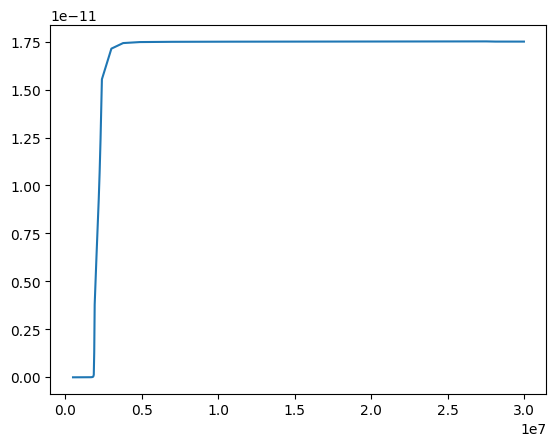

In [703]:
def plotintegrand(lmbda, mphi, m4, E4, theta, r, Sign):
    r_vals = np.linspace(r, 30*Rc, 1000) 
    integrand = lambda r1: (
        Thetaeffsq0mu(lmbda, mphi, m4, E4, theta, r1, Sign)
        # * Gamma_tot_0mu(lmbda, mphi, E4, r1)
    )
    y_vals = [integrand(rv) for rv in r_vals] 
    # plt.xlim(0, 5e6)
    # plt.ylim(0,1e-11)
    plt.plot(r_vals, np.array(y_vals))
    # plt.xscale('log')
    # plt.yscale('log') 

plotintegrand(1,1,7e-6,0.1,np.sqrt(7e-11)/2,Rc/2,1)

In [691]:
Thetaeffsq0mu(1,1,7e-6,0.1,np.sqrt(7e-11)/2,9*Rc,1)

mpf('0.00000000001685805270327552352939735786598715468085765537014962')

In [692]:
print(Tauwithmu(1,1,7e-6,0.1,np.sqrt(7e-11)/2,Rc/2,1))
print(Tauwithmu(1,1,7e-6,0.1,np.sqrt(7e-11)/2,Rc/2,-1))

1.8750789432073505e-11
1.836160895300986e-11


# Differential Luminosity

In [581]:
# def DiffLumi0mu(lmbda, mphi, m4, theta, r, Sign):
#     prefactor = (4 * np.pi * r**2 * (cm_to_invGeV**3) * lmbda**2 * mphi**2) / (16 * np.pi**3)

#     def integrand(E4, E2, E1):
#         term = (E1 + E2 - E4)
#         if term <= 0:
#             return 0.0
#         sqrt_term = np.sqrt((E1 + E2)**2 - mphi**2)
#         if sqrt_term <= 0:
#             return 0.0
#         return (
#             FD(E1, 0, 1e-3 * T(r))
#             * FD(E2, 0, 1e-3 * T(r))
#             * 1.0 / sqrt_term
#             * term
#             * Thetaeffsq0mu(lmbda, mphi, m4, term, theta, r, Sign)
#             * np.exp(-Tau0mu(lmbda, mphi, m4, term, theta, r, Sign))
#         )

#     def bounds_E1():
#         return [0, np.inf]

#     def bounds_E2(E1):
#         return [mphi**2 / (4 * E1), np.inf]

#     def bounds_E4(E1, E2):
#         sqrt_term = np.sqrt((E1 + E2)**2 - mphi**2)
#         return [(0.5 * (E1 + E2 - sqrt_term)), (0.5 * (E1 + E2 + sqrt_term))]

#     result, _ = nquad(integrand, [bounds_E4, bounds_E2, bounds_E1], opts={"epsabs": 1e-6, "epsrel": 1e-5})
#     return prefactor * result * GeVsq_to_Erg_per_s


# def DiffLumiwithmu(lmbda, mphi, m4, theta, r, Sign):
#     prefactor = (4 * np.pi * r**2 * (cm_to_invGeV**3) * lmbda**2 * mphi**2) / (16 * np.pi**3)

#     def integrand(E4, E2, E1):
#         term = (E1 + E2 - E4)
#         if term <= 0:
#             return 0.0
#         sqrt_term = np.sqrt((E1 + E2)**2 - mphi**2)
#         if sqrt_term <= 0:
#             return 0.0
#         return (
#             FD(E1, Sign * 1e-3 * mu_nu(r), 1e-3 * T(r))
#             * FD(E2, Sign * 1e-3 * mu_nu(r), 1e-3 * T(r))
#             * 1.0 / sqrt_term
#             * term
#             * Thetaeffsqwithmu(lmbda, mphi, m4, term, theta, r, Sign)
#             * np.exp(-Tauwithmu(lmbda, mphi, m4, term, theta, r, Sign))
#         )

#     def bounds_E1():
#         return [0, np.inf]

#     def bounds_E2(E1):
#         return [mphi**2 / (4 * E1), np.inf]

#     def bounds_E4(E1, E2):
#         sqrt_term = np.sqrt((E1 + E2)**2 - mphi**2)
#         return [(0.5 * (E1 + E2 - sqrt_term)), (0.5 * (E1 + E2 + sqrt_term))]

#     result, _ = nquad(integrand, [bounds_E4, bounds_E2, bounds_E1], opts={"epsabs": 1e-6, "epsrel": 1e-5})
#     return prefactor * result * GeVsq_to_Erg_per_s

In [582]:
# print(DiffLumi0mu(1,0.1,7e-6,np.sqrt(7e-11)/2,Rc/2,1))
# print(DiffLumi0mu(1,0.1,7e-6,np.sqrt(7e-11)/2,Rc/2,-1))
# print(DiffLumiwithmu(1,0.1,7e-6,np.sqrt(7e-11)/2,Rc/2,1))
# print(DiffLumiwithmu(1,0.1,7e-6,np.sqrt(7e-11)/2,Rc/2,-1))

# Luminosity

In [583]:
# def Lumi0mu(lmbda, mphi, m4, theta, Sign):
#     # make table over r grid
#     temp = [(r, DiffLumi0mu(lmbda, mphi, m4, theta, r, Sign)) for r in rIte]
    
#     # interpolation (linear like Mathematica InterpolationOrder->1)
#     r_vals, y_vals = zip(*temp)
#     ftemp = interp1d(r_vals, y_vals, kind="linear", bounds_error=False, fill_value=0.0)
    
#     # integrate from 0.004 Rc to 4 Rc
#     integrand = lambda r: ftemp(r)
#     Ltemp, _ = quad(integrand, 0.004 * Rc, 4 * Rc, epsabs=1e-6, epsrel=1e-5)
#     return Ltemp


# def Lumiwithmu(lmbda, mphi, m4, theta, Sign):
#     # make table over r grid
#     temp = [(r, DiffLumiwithmu(lmbda, mphi, m4, theta, r, Sign)) for r in rIte]
    
#     # interpolation (linear)
#     r_vals, y_vals = zip(*temp)
#     ftemp = interp1d(r_vals, y_vals, kind="linear", bounds_error=False, fill_value=0.0)
    
#     # integrate from 0.004 Rc to 4 Rc
#     integrand = lambda r: ftemp(r)
#     Ltemp, _ = quad(integrand, 0.004 * Rc, 4 * Rc, epsabs=1e-6, epsrel=1e-5)
#     return Ltemp

# def Luminosity(lmbda, mphi, m4, theta, Sign, use_mu):
#     if use_mu:
#         return Lumiwithmu(lmbda, mphi, m4, theta, Sign)
#     else:
#         return Lumi0mu(lmbda, mphi, m4, theta, Sign)